# Model Card: Loan Default Prediction

## Executive Summary

This project develops a machine learning model to predict the probability that a consumer loan applicant will default. The model is intended to support lending decisions by providing a quantitative estimate of borrower risk based on financial, credit history, and application data from the Home Credit Default Risk dataset.

Several modeling approaches were evaluated during development, including baseline classifiers, logistic regression models, and gradient boosting methods. After comparing performance across models and tuning hyperparameters using cross-validation, a Gradient Boosting classifier was selected as the final model. This model demonstrated strong predictive performance while capturing nonlinear relationships between borrower characteristics and default risk.

The model outputs a probability estimate representing the likelihood that an applicant will default on a loan. This probability can be converted into a lending decision using a chosen decision threshold. Adjusting this threshold allows lenders to balance the tradeoff between approving profitable loans and minimizing losses due to borrower default. A threshold analysis was conducted to explore how different decision boundaries affect business outcomes.

Model transparency was addressed using SHAP (Shapley Additive Explanations), which identifies the most influential features driving model predictions. This approach allows technical model outputs to be translated into understandable factors that explain why certain applicants are considered higher or lower risk.

While the model demonstrates strong predictive capability, several limitations must be considered before deployment. The model relies on historical lending data, which may reflect past biases in credit decision processes. Additionally, borrower behavior and macroeconomic conditions may change over time, potentially reducing model accuracy in future environments. For these reasons, the model should be used as a decision-support tool rather than a fully automated approval system, with human oversight incorporated into the lending process.


## Model Details

Model Type: Gradient Boosting Classifier (scikit-learn)

The final model is a GradientBoostingClassifier trained on the Home Credit Default Risk dataset.

The modeling process evaluated several baseline and candidate models including:

- DummyClassifier (baseline)
- Logistic Regression
- Class-weighted Logistic Regression
- Gradient Boosting
- Gradient Boosting with SMOTE oversampling

The final model was selected after cross-validation and hyperparameter tuning using RandomizedSearchCV.

Training was performed using stratified splits to preserve the class imbalance present in the default prediction problem.

## Intended Use

This model is designed to estimate the probability that a loan applicant will default.

Primary users:
Credit risk analysts and lending institutions evaluating consumer loan applications.

Decision supported:
Whether to approve or reject a loan application based on predicted default probability.

Out-of-scope uses:
The model should not be used as the sole decision-maker for loan approvals. Human review should remain part of the process, especially for borderline cases.

The model is trained on historical credit data and may not generalize perfectly to new economic conditions.

## Performance Metrics

Model performance was evaluated using several metrics that measure the ability of the model to distinguish between borrowers who will default and those who will repay their loans.

The primary evaluation metric is **Area Under the ROC Curve (AUC)**, which measures how well the model ranks higher-risk borrowers relative to lower-risk borrowers. Because the dataset is highly imbalanced, AUC provides a more reliable measure of performance than accuracy alone.

In addition to AUC, **precision and recall** were evaluated at the chosen decision threshold. Precision measures the proportion of predicted defaults that were correct, while recall measures the proportion of actual defaults correctly identified by the model.

Model performance was assessed using cross-validation during model development, and the final model was also evaluated using the Kaggle competition leaderboard score. Reporting both metrics provides a comparison between internal validation and external evaluation on the competition dataset.

The model achieves an AUC of approximately 0.72, indicating reasonable ranking performance. Due to class imbalance (default rate ~8%), predicted probabilities are relatively low, making threshold selection critical.

At a threshold of 0.2, the model achieves higher precision but low recall, missing many defaulters. Lowering the threshold to 0.1 substantially improves recall but introduces a large number of false positives.

A threshold of 0.15 provides a balance between these extremes, achieving a precision of approximately 0.24 and recall of 0.28. This threshold improves the model’s ability to detect defaulters while maintaining a reasonable level of prediction accuracy, making it a suitable compromise for decision-making.

The model achieved a cross-validated AUC of approximately 0.72, and a similar performance was observed on the Kaggle leaderboard (a private submission score of 0.70 and a public score of 0.72) , indicating consistent generalization to unseen data.


## Decision Threshold Analysis

### Business Cost Assumptions

In consumer lending, different types of prediction errors have different financial consequences. When a borrower defaults, the loan may eventually be written off as a non-performing asset (NPA), resulting in significant losses for the lending institution. 

As noted in credit risk literature (Home Credit case study), misclassifying a high-risk borrower as low-risk (false negative) is particularly costly because it can lead to unrecovered loans and financial losses. In contrast, misclassifying a low-risk borrower as high-risk (false positive) results in a missed opportunity but does not directly incur a loss.

Therefore, the cost of false negatives is substantially higher than the cost of false positives.


### Threshold Selection

Three thresholds were evaluated:

- **0.20**: Higher precision but very low recall, missing many defaulters
- **0.10**: High recall (~0.52) but very low precision, resulting in many false positives
- **0.15**: Balanced performance with precision ≈ 0.24 and recall ≈ 0.28

Given the high cost of misclassifying defaulters, a threshold of **0.15** provides the best tradeoff. It improves the model’s ability to detect risky borrowers while limiting excessive false positives.


### Sensitivity Analysis

Model performance varies significantly across thresholds:

- Lower thresholds increase recall but lead to more false positives (rejecting good borrowers)
- Higher thresholds improve precision but miss more defaulters, increasing financial risk
- A threshold of 0.15 balances these tradeoffs

This demonstrates that threshold selection has a direct impact on business outcomes and must align with the organization’s risk tolerance.

## References

- Home Credit Default Risk Dataset (Kaggle)
- Credit risk modeling case study and analysis (Medium article based on Home Credit data)

## Model Explainability (SHAP Analysis)

To improve interpretability of the model, SHAP (Shapley Additive Explanations) was used to identify the most important features influencing predictions. The SHAP summary plot provides a global view of feature importance as well as the direction of each feature’s impact on the model output.

The results show that features such as **EXT_SOURCE_3_MISSING**, **ANNUITY_TO_INCOME**, and **MEAN_PAYMENT_DELAY** are among the most influential in predicting loan default. In particular, higher values of **ANNUITY_TO_INCOME** are associated with an increased likelihood of default, indicating that applicants with higher debt relative to income are riskier. Additionally, longer payment delays contribute positively to default risk, reflecting past repayment behavior.

Conversely, stronger external credit indicators (such as external source scores) are associated with lower default risk, suggesting that applicants with better credit history are more likely to repay their loans.

Overall, these findings align with financial intuition: applicants with higher financial burden and weaker repayment history are more likely to default, while those with stronger credit profiles are less risky.


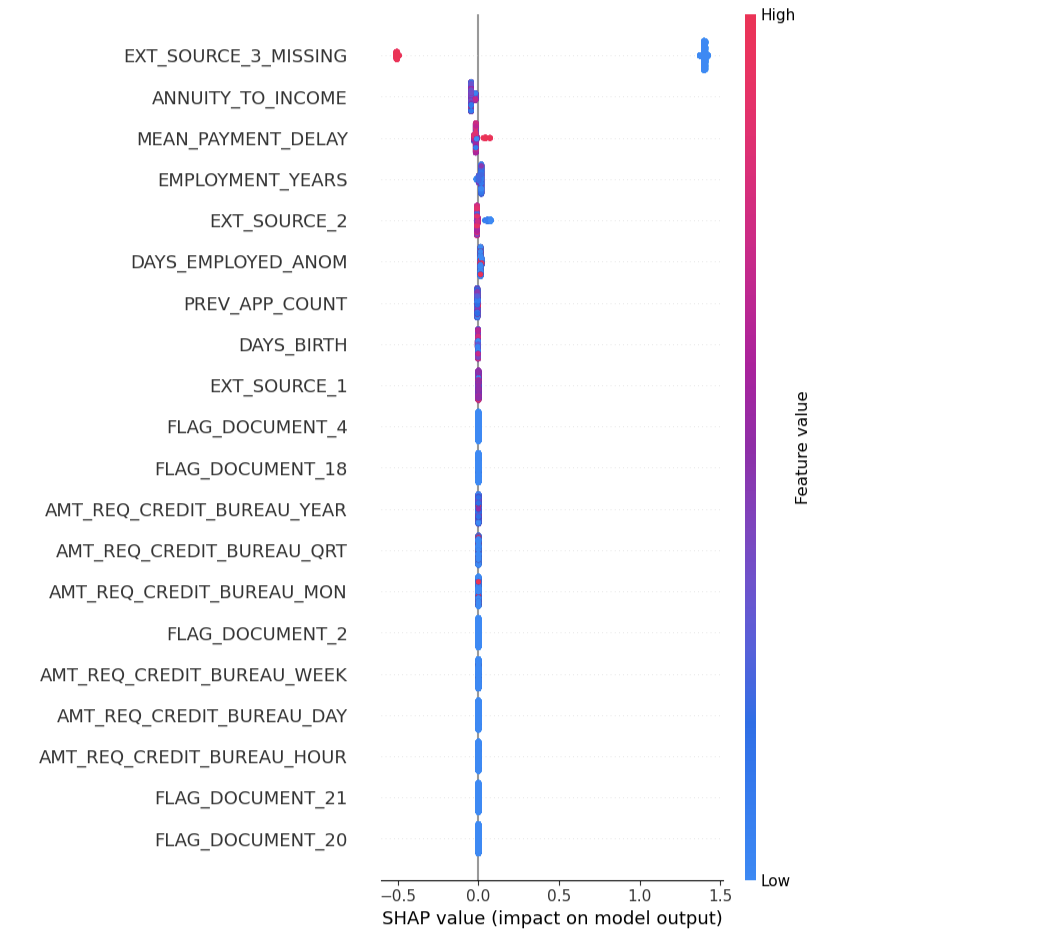

In [1]:
from IPython.display import Image, display

display(Image(filename='shap_plot.png'))

## Adverse Action Mapping

To ensure transparency and comply with lending regulations, key model features were translated into human-readable explanations for loan decisions.

- **High ANNUITY_TO_INCOME** → The applicant has a high debt burden relative to their income, indicating financial strain.
- **Low EXT_SOURCE scores** → The applicant has a limited or weak external credit history.
- **High MEAN_PAYMENT_DELAY** → The applicant has a history of late payments, suggesting potential repayment risk.
- **Low EMPLOYMENT_YEARS** → The applicant has limited employment history, which may indicate income instability.

These explanations help provide clear and actionable reasons for loan denial decisions, making the model outputs more interpretable for both applicants and financial institutions.

## Fairness Analysis

Approval rates were analyzed across demographic groups to assess potential disparities in model outcomes.

Across gender, female applicants have a slightly higher approval rate (91.7%) compared to male applicants (88.7%), indicating a modest difference in model decisions. The category labeled "XNA" shows a substantially lower approval rate, though this likely reflects a very small or irregular subset of the data.

Across education levels, applicants with higher education exhibit the highest approval rate (93.0%), while those with academic degrees and incomplete higher education have lower approval rates. This suggests that education level is associated with model decisions, with more educated applicants generally receiving more favorable outcomes.

Overall, while differences in approval rates are present across both gender and education groups, the disparities are relatively moderate. These results highlight the importance of monitoring model behavior across demographic groups to ensure equitable outcomes.

## Limitations and Risks

While the model demonstrates reasonable predictive performance, several limitations should be considered.

First, the model is trained on historical lending data, which may contain biases or reflect past decision-making practices. As a result, the model may unintentionally learn and reproduce existing patterns in the data, potentially leading to unequal outcomes across demographic groups.

Second, the model relies heavily on engineered and proxy features (such as external credit scores and payment behavior), which may not fully encompass a borrower’s financial situation. Important factors such as recent income changes, informal financial support, sudden life events, or economic conditions are not included, which may limit the model’s ability to generalize.

Additionally, the dataset represents a specific population and time period, meaning the model may not perform as well if deployed in a different economic environment or for a different group of applicants. Changes in macroeconomic conditions, such as recessions or shifts in lending policy, could significantly impact model performance.

There are also risks associated with threshold selection. While a threshold of 0.15 improves recall and helps identify high-risk borrowers, it increases the number of false positives, potentially leading to the rejection of creditworthy applicants.

From a deployment perspective, there is a risk that model predictions may be over-relied upon without sufficient human intervention. Given regulatory requirements in lending, decisions must remain explainable and justifiable, and the model should be used as a decision-support tool rather than a fully automated system.

Overall, these limitations highlight the importance of ongoing monitoring, periodic retraining, and careful consideration of fairness and regulatory compliance when deploying the model in practice.